**Logistic Regression Classification**


####Importing Libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

####Importing Dataset

In [4]:
dataset=pd.read_csv('breast_cancer.csv')
x=dataset.iloc[:,:-1].values
y=dataset.iloc[:,-1].values

In [5]:
print(x)

[[8.4230200e+05 1.7990000e+01 1.0380000e+01 ... 2.6540000e-01
  4.6010000e-01 1.1890000e-01]
 [8.4251700e+05 2.0570000e+01 1.7770000e+01 ... 1.8600000e-01
  2.7500000e-01 8.9020000e-02]
 [8.4300903e+07 1.9690000e+01 2.1250000e+01 ... 2.4300000e-01
  3.6130000e-01 8.7580000e-02]
 ...
 [9.2695400e+05 1.6600000e+01 2.8080000e+01 ... 1.4180000e-01
  2.2180000e-01 7.8200000e-02]
 [9.2724100e+05 2.0600000e+01 2.9330000e+01 ... 2.6500000e-01
  4.0870000e-01 1.2400000e-01]
 [9.2751000e+04 7.7600000e+00 2.4540000e+01 ... 0.0000000e+00
  2.8710000e-01 7.0390000e-02]]


In [6]:
print(y)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 0 1 1 1 1 1 1 1 1 0 1 0 0 0 0 0 1 1 0 1 1 0 0 0 0 1 0 1 1 0 0 0 0 1 0 1 1
 0 1 0 1 1 0 0 0 1 1 0 1 1 1 0 0 0 1 0 0 1 1 0 0 0 1 1 0 0 0 0 1 0 0 1 0 0
 0 0 0 0 0 0 1 1 1 0 1 1 0 0 0 1 1 0 1 0 1 1 0 1 1 0 0 1 0 0 1 0 0 0 0 1 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 1 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 1
 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 0 1 1 1 0 1 0 1 0 0 1 0 1 1 1 1 0 0 1 1 0 0
 0 1 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 1 0 1 0 1 0 0 0 1 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1
 1 0 1 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 1 0 0 0 0 0 1 0 0
 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 1 0 1 0 0 1 

####Splitting the Dataset into Training &
  Test set

In [7]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=0)


####Feature Scaling

In [8]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [9]:
print(X_train)

[[-0.232028   -0.74998027 -1.09978744 ... -0.6235968   0.07754241
   0.45062841]
 [-0.23217735 -1.02821446 -0.1392617  ... -0.7612376  -1.07145262
  -0.29541379]
 [-0.17081111 -0.53852228 -0.29934933 ... -0.50470441  0.34900827
  -0.13371556]
 ...
 [ 6.83303935 -1.3214733  -0.20855336 ... -0.98621857 -0.69108476
  -0.13148524]
 [-0.23231516 -1.24245479 -0.23244704 ... -1.7562754  -1.55125275
  -1.01078909]
 [-0.2319212  -0.74441558  1.13188181 ... -0.28490593 -1.2308599
   0.20083251]]


In [10]:
print(X_test)

[[-0.23199655 -0.21855296  0.31710749 ...  1.36998461  1.0939611
   1.51560644]
 [-0.1676608  -0.27141746  1.44727832 ... -0.84095647 -0.70686766
  -0.88310324]
 [-0.23204585 -0.04604776 -0.84412512 ... -0.50394228 -1.19298094
  -0.92659449]
 ...
 [-0.23197925 -0.13230036 -0.12253613 ...  0.20087616 -0.06766026
   0.36754897]
 [-0.23211154 -0.24637638  0.56799108 ... -0.90055508 -0.40225771
  -0.95558866]
 [-0.23192865 -1.35013142  0.65639767 ... -1.36545479 -0.72107227
  -0.54576727]]


####Logistic Regression Training on Training Set

In [11]:
from sklearn.linear_model import LogisticRegression
classifier=LogisticRegression(random_state=0)
classifier.fit(X_train,y_train)

LogisticRegression(random_state=0)

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

In [13]:
from sklearn.svm import SVC
# SVM Model Training

svm = SVC(kernel='linear', probability=True, random_state=0)

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# Neural Network Model

nn = Sequential()

# Input + Hidden Layer
nn.add(Dense(units=16,
             activation='relu',
             input_dim=X_train.shape[1]))

# Hidden Layer
nn.add(Dense(units=8,
             activation='relu'))

# Output Layer
nn.add(Dense(units=1,
             activation='sigmoid'))
nn.compile(optimizer='adam',
           loss='binary_crossentropy',
           metrics=['accuracy'])
history = nn.fit(X_train,
                 y_train,
                 epochs=50,
                 batch_size=32,
                 validation_data=(X_test, y_test))
nn_prob = nn.predict(X_test)
nn_pred = (nn_prob > 0.5).astype(int)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.4623 - loss: 0.7756 - val_accuracy: 0.5556 - val_loss: 0.6767
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.6633 - loss: 0.6121 - val_accuracy: 0.7544 - val_loss: 0.5397
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7990 - loss: 0.4921 - val_accuracy: 0.8655 - val_loss: 0.4351
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8869 - loss: 0.3978 - val_accuracy: 0.8830 - val_loss: 0.3559
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9171 - loss: 0.3278 - val_accuracy: 0.9181 - val_loss: 0.2951
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9397 - loss: 0.2753 - val_accuracy: 0.9357 - val_loss: 0.2501
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9447 - loss: 0.2352 - val_accuracy: 0.9415 - val_loss: 0.2165
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9497 - loss: 0.2066 - val_accuracy: 0.9415 - val_loss: 0.

####Confusion Matrix

In [21]:
from sklearn.metrics import confusion_matrix,accuracy_score
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
#logistic regression

print("\n==============================")
print("LOGISTIC REGRESSION")
print("==============================")

y_pred=classifier.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print(cm)
print("logistic regression Accuracy:", accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))
scores = cross_val_score(classifier, X_train, y_train, cv=5)
print("Cross-validation accuracy:", scores.mean())

#random forest classifer

print("\n==============================")
print("Random Forest Classifier")
print("==============================")

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
rf_cm = confusion_matrix(y_test, rf_pred)
print("Confusion Matrix:\n", rf_cm)
print("Classification Report:\n", classification_report(y_test, rf_pred))
rf_scores = cross_val_score(rf, X_train, y_train, cv=5)
print("Random Forest Cross-validation scores:", rf_scores)
print("Mean Accuracy:", rf_scores.mean())


#SVM

print("\n==============================")
print("SVM")
print("==============================")

print("SVM Accuracy:", accuracy_score(y_test, svm_pred))
svm_cm = confusion_matrix(y_test, svm_pred)
print("Confusion Matrix:\n", svm_cm)
print("Classification Report:\n", classification_report(y_test, svm_pred))
svm_scores = cross_val_score(svm, X_train, y_train, cv=5)
print("SVM Cross-validation scores:", svm_scores)
print("Mean Accuracy:", svm_scores.mean())

#neural network

print("\n==============================")
print("Nueral Network")
print("==============================")

print("Neural Network Accuracy:",
      accuracy_score(y_test, nn_pred))
nn_cm = confusion_matrix(y_test, nn_pred)
print("Confusion Matrix:\n", nn_cm)
print("Classification Report:\n",
      classification_report(y_test, nn_pred))


LOGISTIC REGRESSION
[[104   4]
 [  3  60]]
logistic regression Accuracy: 0.9590643274853801
              precision    recall  f1-score   support

           0       0.97      0.96      0.97       108
           1       0.94      0.95      0.94        63

    accuracy                           0.96       171
   macro avg       0.95      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171

Cross-validation accuracy: 0.9824683544303797

Random Forest Classifier
Random Forest Accuracy: 0.9707602339181286
Confusion Matrix:
 [[104   4]
 [  1  62]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.96      0.98       108
           1       0.94      0.98      0.96        63

    accuracy                           0.97       171
   macro avg       0.96      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

Random Forest Cross-validation scores: [0.9625     0.9        0.9625    

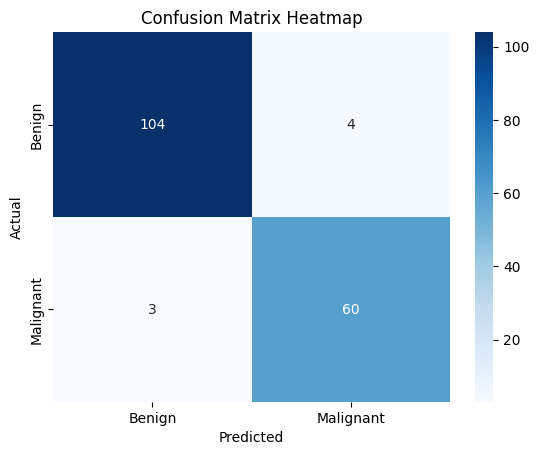

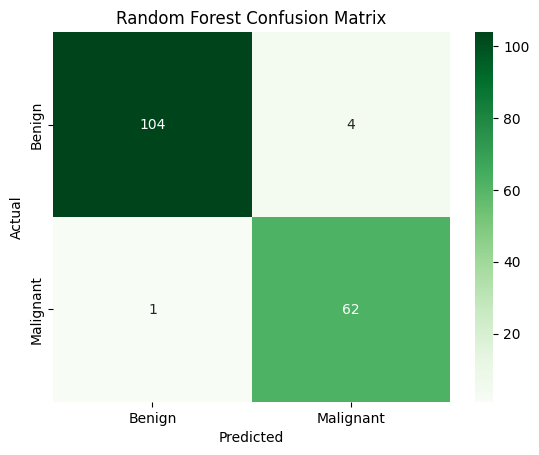

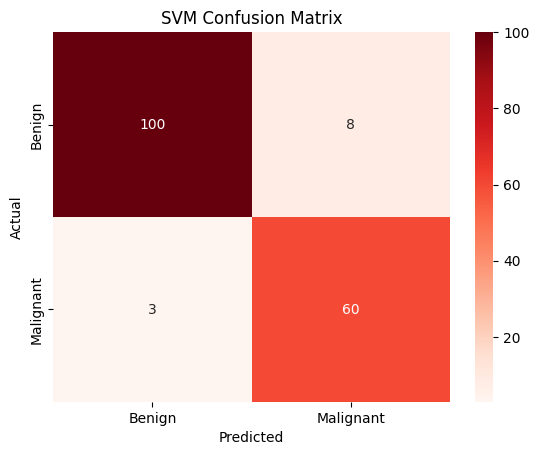

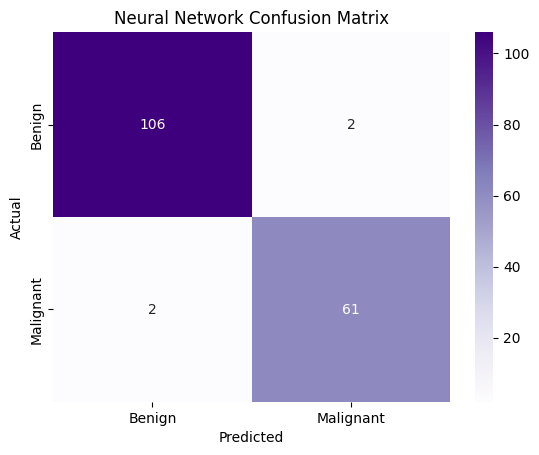

In [16]:
#logistic regression
labels = ['Benign', 'Malignant']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix Heatmap")
plt.show()


#random forest classfier
labels = ['Benign', 'Malignant']

sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# SVM
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=labels,
            yticklabels=labels)

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

#NUERAL NETWORK
sns.heatmap(nn_cm,
            annot=True,
            fmt='d',
            cmap='Purples',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Neural Network Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

AUC Score: 0.9875073486184597


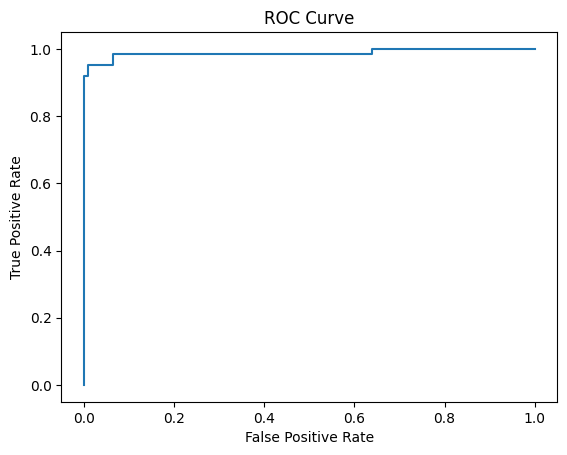

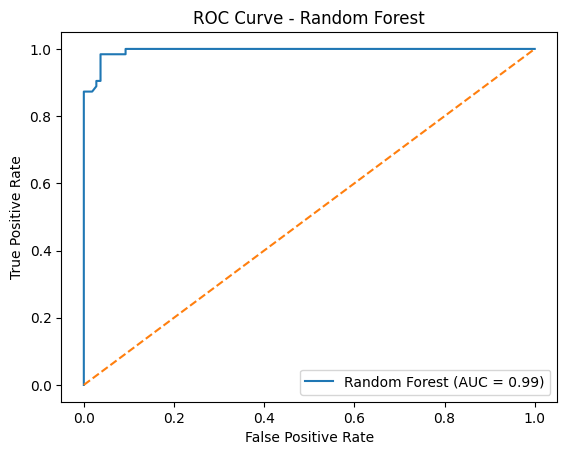

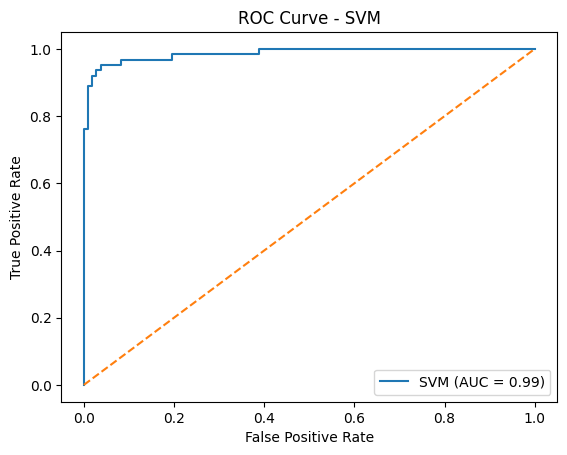

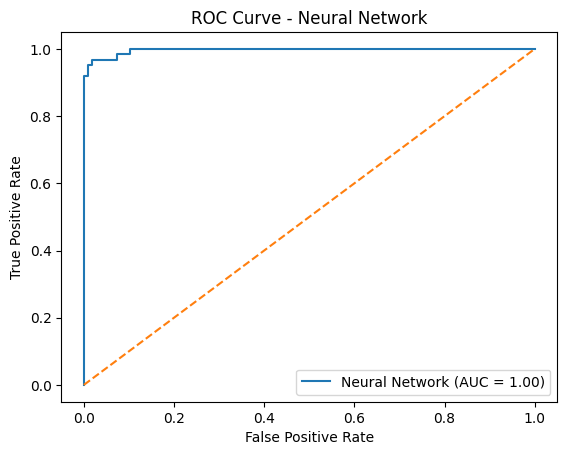

In [17]:
#logistic regression
from sklearn.metrics import roc_curve, auc
y_prob = classifier.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_auc_score
print("AUC Score:", roc_auc_score(y_test, y_prob))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()


#random forest classfier
rf_prob = rf.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr_rf, tpr_rf, label="Random Forest (AUC = %.2f)" % roc_auc_score(y_test, rf_prob))
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.show()

# SVM
svm_prob = svm.predict_proba(X_test)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)
plt.plot(fpr_svm, tpr_svm,
         label="SVM (AUC = %.2f)" % roc_auc_score(y_test, svm_prob))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()
plt.show()

#nueral network
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_prob)

plt.plot(fpr_nn,
         tpr_nn,
         label="Neural Network (AUC = %.2f)"
         % roc_auc_score(y_test, nn_prob))

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Neural Network")
plt.legend()
plt.show()

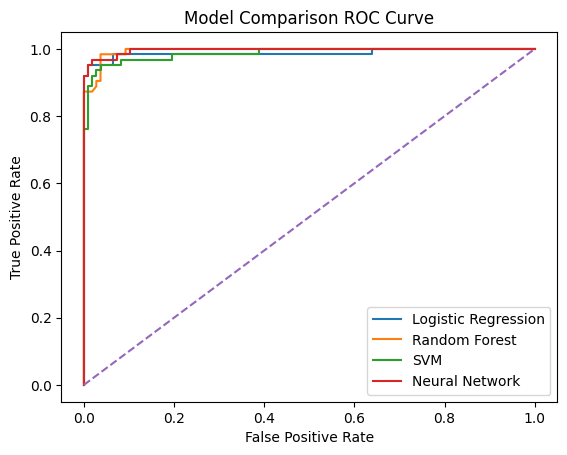

In [18]:
# Logistic Regression vs random forest classfier vs SVM vs Nueral network

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_svm, tpr_svm, label="SVM")
plt.plot(fpr_nn, tpr_nn, label="Neural Network")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Model Comparison ROC Curve")
plt.legend()
plt.show()